# **Creación de data tabular de la señales fisiológicas obtenidas de EMG y ECG**

In [1]:
# Importación de librerías
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

In [2]:
# Seleccionamos estilo de ploteo
plt.style.use("ggplot")

## Lectura de los datos ECG

In [3]:
def leertxt(filename: str, header: int = 2, delimiter: str = ",", media: bool = True) -> tuple[np.ndarray, int]:
    # Abrimos el archivo txt para ver  el contenido
    f = open(filename, "r")
    raw_data = f.readline()  # con f.read() leemos todo el contenido
    f.close()

    ## Expresion regular para buscar automaticamente el contenido de un numero dentro de un string
    x = re.findall("\d+", raw_data)
    # Fs = float(x[0])
    Fs = int(x[0])

    # Leemos el archivo excluyendo las 2 primeras filas del archivo
    array = np.genfromtxt("./" + filename, delimiter=delimiter, skip_header=header)
    if media: array[:, 1:] = array[:, 1:] - np.mean(array[:, 1])  # le restamos la media
    array[:, 0] = np.arange(0, len(array[:, 0]))

    return array, Fs


array1, Fs = leertxt("ecg1.txt")
array2 = leertxt("ecg2.txt")[0]  # Fs es la misma en ambos archivos
Fs

1000

In [4]:
# Nos quedamos con el dato del sensor
def segmentar(array: np.ndarray, start: int, end: int, fs: int = Fs): return array[(fs * start) : (fs * end), 1]


basal11 = segmentar(array1, 0, 30)
inhex1 = segmentar(array1, 30, 62)
basal12 = segmentar(array1, 62, 92)

basal21 = segmentar(array2, 0, 30)
inhex2 = segmentar(array2, 30, 80)
basal22 = segmentar(array2, 80, 118)

## Especificar la Frecuencia de muestreo para medicion ECG 

---



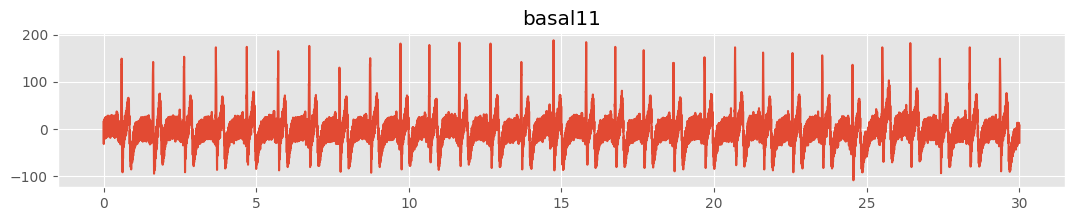

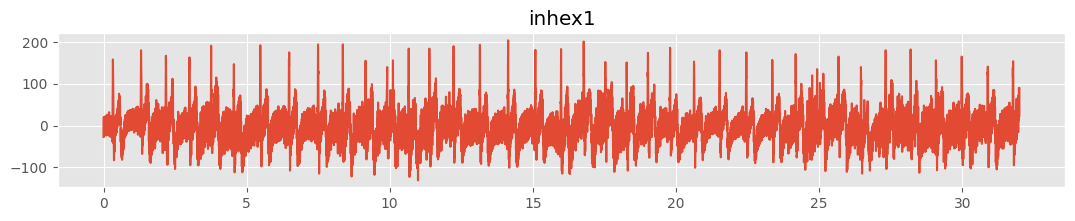

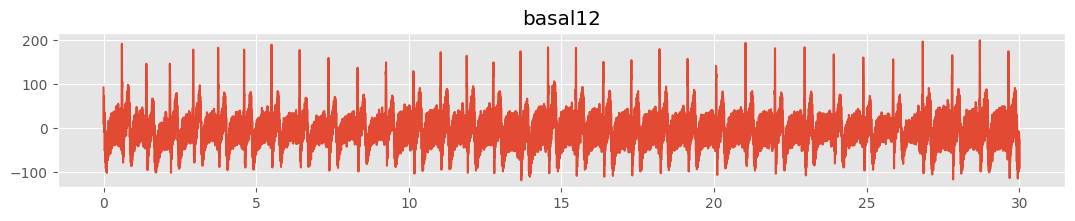

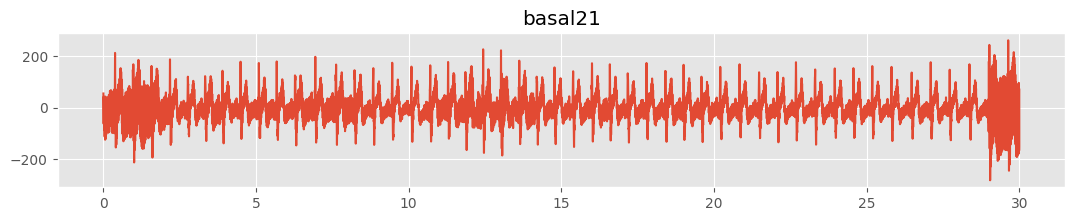

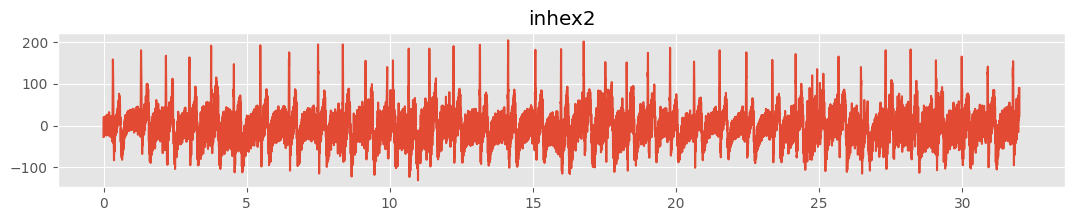

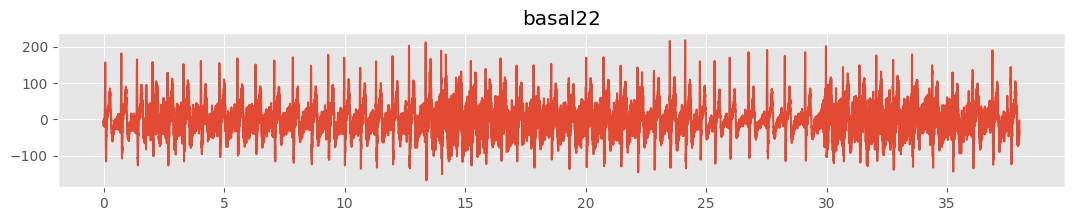

In [5]:
# Ploteamos las señales en el tiempo
def plotear(array: np.ndarray, title: str, fs: int = Fs):
    Ts = 1 / fs
    n = np.arange(0, array.shape[0])  # t = n*Ts
    t = n * Ts
    plt.figure(figsize=(13, 2))
    plt.title(title)
    plt.plot(t, array)


plotear(basal11, "basal11")
plotear(inhex1, "inhex1")
plotear(basal12, "basal12")
plotear(basal21, "basal21")
plotear(inhex1, "inhex2")
plotear(basal22, "basal22")

## Pasando a data tabular estilo Sklearn

In [6]:
def deefe(array: np.ndarray, ntarget: int, col: int = 100, fs: int = Fs) -> tuple[np.ndarray, np.ndarray]:
    Ts = 1 / fs
    n = np.arange(0, array.shape[0])  # t = n*Ts
    t = n * Ts

    # Pasamos las observaciones a filas correspondientes a una variable t y d_sensor
    st_sensor = np.concatenate((t.reshape(-1, 1), array.reshape(-1, 1)), axis=1)
    # Creamos el data frame con las varibles t y d_sensor
    df = pd.DataFrame(st_sensor, columns=["t", "d_sensor"])
    df.head()
    # Establecemos t como index
    df = df.set_index("t")

    d_obs = df[["d_sensor"]].values.reshape(int(array.shape[0] / col), col)
    target = np.repeat(ntarget, d_obs.shape[0])
    return d_obs, target


obs_basal11, target_basal11 = deefe(basal11, 0)
obs_inhex1, target_inhex1 = deefe(inhex1, 1)
obs_basal12, target_basal12 = deefe(basal12, 2)

obs_basal21, target_basal21 = deefe(basal21, 3)
obs_inhex2, target_inhex2 = deefe(inhex2, 4)
obs_basal22, target_basal22 = deefe(basal22, 5)

## Descripción de categoria de los ejercicios realizado en la clase de ECG

| Descripción | Categoría |
|----------|----------|
|Basal 11                   |0|
|Inhalación y exhalación 1  |1|
|Basal 12                   |2|
|Basal 21                   |3|
|Inhalación y exhalación 2  |4|
|Basal 22                   |5|

* **Basal 11:** Primera medición en reposo basal.
* **Inhalación y exhalación 1:** Periodo de inhalación y exhalación.
* **Basal 12:** Segunda medición en reposo basal.
* **Basal 21:** Primera medición en reposo basal luego del ejercicio.
* **Inhalación y exhalación 2:** Periodo de inhalación y exhalación luego del ejercicio.
* **Basal 22:** Segunda medición en reposo basal luego del ejercicio.

In [7]:
ecg = {
    "base": np.concatenate(
        [obs_basal11, obs_inhex1, obs_basal12, obs_basal12, obs_inhex2, obs_basal22]
    ),
    "target": [
        target_basal11,
        target_inhex1,
        target_basal12,
        target_basal21,
        target_inhex2,
        target_basal22,
    ],
}
ecg

{'base': array([[ 15.25121505,   8.25121505,   5.25121505, ...,  19.25121505,
          22.25121505,  24.25121505],
        [ 25.25121505,  20.25121505,  17.25121505, ...,  17.25121505,
          21.25121505,  25.25121505],
        [ 25.25121505,  21.25121505,  17.25121505, ...,  16.25121505,
          20.25121505,  24.25121505],
        ...,
        [-42.81330029, -42.81330029, -39.81330029, ...,  54.18669971,
          52.18669971,  55.18669971],
        [ 54.18669971,  51.18669971,  45.18669971, ...,  20.18669971,
          20.18669971,  16.18669971],
        [  4.18669971,  -9.81330029, -17.81330029, ...,  -9.81330029,
          -2.81330029,  -2.81330029]]),
 'target': [array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

In [8]:
import pickle

with open("dataset_EEG.pkl", "wb") as f:
    pickle.dump(ecg, f)